**Import Packages:**

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.signal import find_peaks

**Define Functions for Analysis**

In [65]:
# Define second gradient function
def second_gradient(i):
    di = np.gradient(i)
    y = gaussian_filter1d(np.gradient(di),sigma=2)
    return y

# Define function to get x and y position of peaks
def peaks(r,y,h):
    p = find_peaks(y,height=h,distance=20) # The Numpy find peaks function gives the intensity of the peaks
    py = p[1]['peak_heights'] # Get the y value of peak position
    px = r[p[0]] # Get the x value of peak position
    return px,py

# Define function to import data
def dataimport(pathd,pathb,h): # Set path to the data file, background data file, and minimum height for peak identification
    a = pd.read_csv(pathd,sep=',',names=['wave','ref']) # Read file of sample measurement
    b = pd.read_csv(pathb,sep=',',names=['bwave','bref']) # Read file of background measurement
    w = np.asarray(a.wave)
    r = np.asarray(a.ref)
    rb = np.asarray(b.bref)
    rbs = r-rb # Subtract background measurement
    y = second_gradient(rbs) # Return second gradient of background subtracted reflectance
    px,py = peaks(w,y,h) # Return peak positions
    return w,y,px,py

**Import Data**

In [66]:
# Cultural (unknown) samples
n1w,n1y,n1px,n1py = dataimport('Data/NN01_NI_260204.csv','Data/NN01_BACK_NI_260204.csv',0.00015)
n2w,n2y,n2px,n2py = dataimport('Data/NN02_NI_260204.csv','Data/NN02_BACK_NI_260204.csv',0.00015)
n3w,n3y,n3px,n3py = dataimport('Data/NN03_NI_260310.csv','Data/NN03_BACK_NI_260310.csv',0.00015)
n4w,n4y,n4px,n4py = dataimport('Data/NN04_NI_260310.csv','Data/NN04_BACK_NI_260310.csv',0.00015)
n5w,n5y,n5px,n5py = dataimport('Data/NN05_NI_260310.csv','Data/NN05_BACK_NI_260310.csv',0.00015)
n6w,n6y,n6px,n6py = dataimport('Data/NN06_NI_260204.csv','Data/NN06_BACK_NI_260204.csv',0.00015)
n7w,n7y,n7px,n7py = dataimport('Data/NN07_NI_260310.csv','Data/NN07_BACK_NI_260310.csv',0.0001)

# Model (known) samples
kw,ky,kpx,kpy = dataimport('Data/M08_25-09-1000000.csv','Data/M08_BACK_25-09-1000000.csv',0.0004)
qw,qy,qpx,qpy = dataimport('Data/M01_25-09-1000000.csv','Data/M01_BACK_25-09-1000000.csv',0.00015)

# Add hematite data without using dataimport function, as the format is different (data taken from https://www.rruff.net/odr/rruff_sample#/odr/view/640207/2010/eyI3MDUyIjoiaGVtYXRpdGUiLCJkdF9pZCI6IjczOCIsInNvcnRfYnkiOlt7InNvcnRfZGZfaWQiOiI3MDUyIiwic29ydF9kaXIiOiJhc2MifV19/1)
ha = pd.read_csv('Data/RRUFF_Hematite_NI_R040024.csv',sep=',',names=['wave','ref'])
hw = np.asarray(ha.wave)
hr = np.asarray(ha.ref)
hy = second_gradient(hr)
hpx,hpy = peaks(hw,hy,0.000026)

**Define Functions for Plotting**

In [67]:
# Define function to put coloured vertical lines along x values of model samples peaks
def vertlines(px,py,color):
    for i,j in zip(px,py):
        if i == 1003:
            pass # The peak at 1003 is an artifact of the spectroscopy process which appears on any sample, so no need to label it
        else:
            plt.axvline(x=i,color=color,linewidth=0.7,ls='--',alpha=0.5)

# Define function to plot cultural sample data
def culturalplot(w,y,px,py,ymin,ymax,label,top=None): # Set parameters for variables, y axis limits, labels,
    if top:                                           # and whether the subplot is at the top
        frame1 = plt.gca()
        plt.plot(w,y,c='Black',linewidth=1) # Plot spectrum
        plt.plot(px,py,"x") # Plot peak positions
        plt.xlim(500,2000) # Set limits
        plt.ylim(ymin,ymax)
        plt.gca().yaxis.set_label_position("right") # Place the y axis on the right
        plt.ylabel(label) # Label the sample ID
        frame1.axes.get_yaxis().set_ticks([]) # Don't show ticks on axis
        frame1.axes.get_xaxis().set_ticks([])
        frame1.spines['bottom'].set_visible(False) # Don't show lower border for subplot
        vertlines(kpx,kpy,'Green') # Plot vertical lines
        vertlines(hpx,hpy,'Orange')
        vertlines(qpx,qpy,'Grey')
    else:
        frame1 = plt.gca()
        plt.plot(w,y,c='Black',linewidth=1)
        plt.plot(px,py,"x")
        plt.xlim(500,2000)
        plt.ylim(ymin,ymax)
        plt.gca().yaxis.set_label_position("right")
        plt.ylabel(label)
        frame1.axes.get_yaxis().set_ticks([])
        frame1.axes.get_xaxis().set_ticks([])
        frame1.spines['top'].set_visible(False) # Don't show lower or upper border for subplot
        frame1.spines['bottom'].set_visible(False) 
        vertlines(kpx,kpy,'Green')
        vertlines(hpx,hpy,'Orange')
        vertlines(qpx,qpy,'Grey')

# Define function to plot model sample data
def modelplot(w,y,px,py,ymin,ymax,label,color,bottom=None): # Set parameters for variables, y axis limits, labels, 
    if bottom:                                              # color, and whether the subplot is at the bottom
        frame1 = plt.gca()
        plt.plot(w,y,c=color,linewidth=1)
        plt.plot(px,py,"x",color=color)
        for i,j in zip(px,py): # Label the x position of the peaks
            if i == 1003:
                pass
            else:
                plt.annotate(np.round(i,decimals=1),xy=(i,j),xytext=(-1,5),textcoords='offset points',color=color)
        plt.xlim(500,2000)
        plt.ylim(ymin,ymax)
        plt.gca().yaxis.set_label_position("right")
        plt.ylabel(label,color=color)
        plt.xlabel('Wavelength')
        frame1.axes.get_yaxis().set_ticks([])
        frame1.spines['top'].set_visible(False) 
        vertlines(kpx,kpy,'Green')
        vertlines(hpx,hpy,'Orange')
        vertlines(qpx,qpy,'Grey')
    else:
        frame1 = plt.gca()
        plt.plot(w,y,c=color,linewidth=1)
        plt.plot(px,py,"x",color=color)
        for i,j in zip(px,py):
            if i == 1003:
                pass
            else:    
                plt.annotate(np.round(i,decimals=1),xy=(i,j),xytext=(-1,5),textcoords='offset points',color=color)
        plt.xlim(500,2000)
        plt.ylim(ymin,ymax)
        plt.gca().yaxis.set_label_position("right")
        plt.ylabel(label,color=color)
        frame1.axes.get_yaxis().set_ticks([])
        frame1.axes.get_xaxis().set_ticks([])
        frame1.spines['top'].set_visible(False)
        frame1.spines['bottom'].set_visible(False)  
        vertlines(kpx,kpy,'Green')
        vertlines(hpx,hpy,'Orange')
        vertlines(qpx,qpy,'Grey')

**Set Plot Parameters**

In [68]:
plt.rcParams['font.sans-serif'] = 'Noto Sans' # Set font
plt.rcParams['font.size'] = 9 # Set font size
plt.rcParams['figure.facecolor'] = 'White' # Set background colour
plt.rcParams['figure.dpi'] = 600 # Set figure resolution as DPI

**Create Plot**

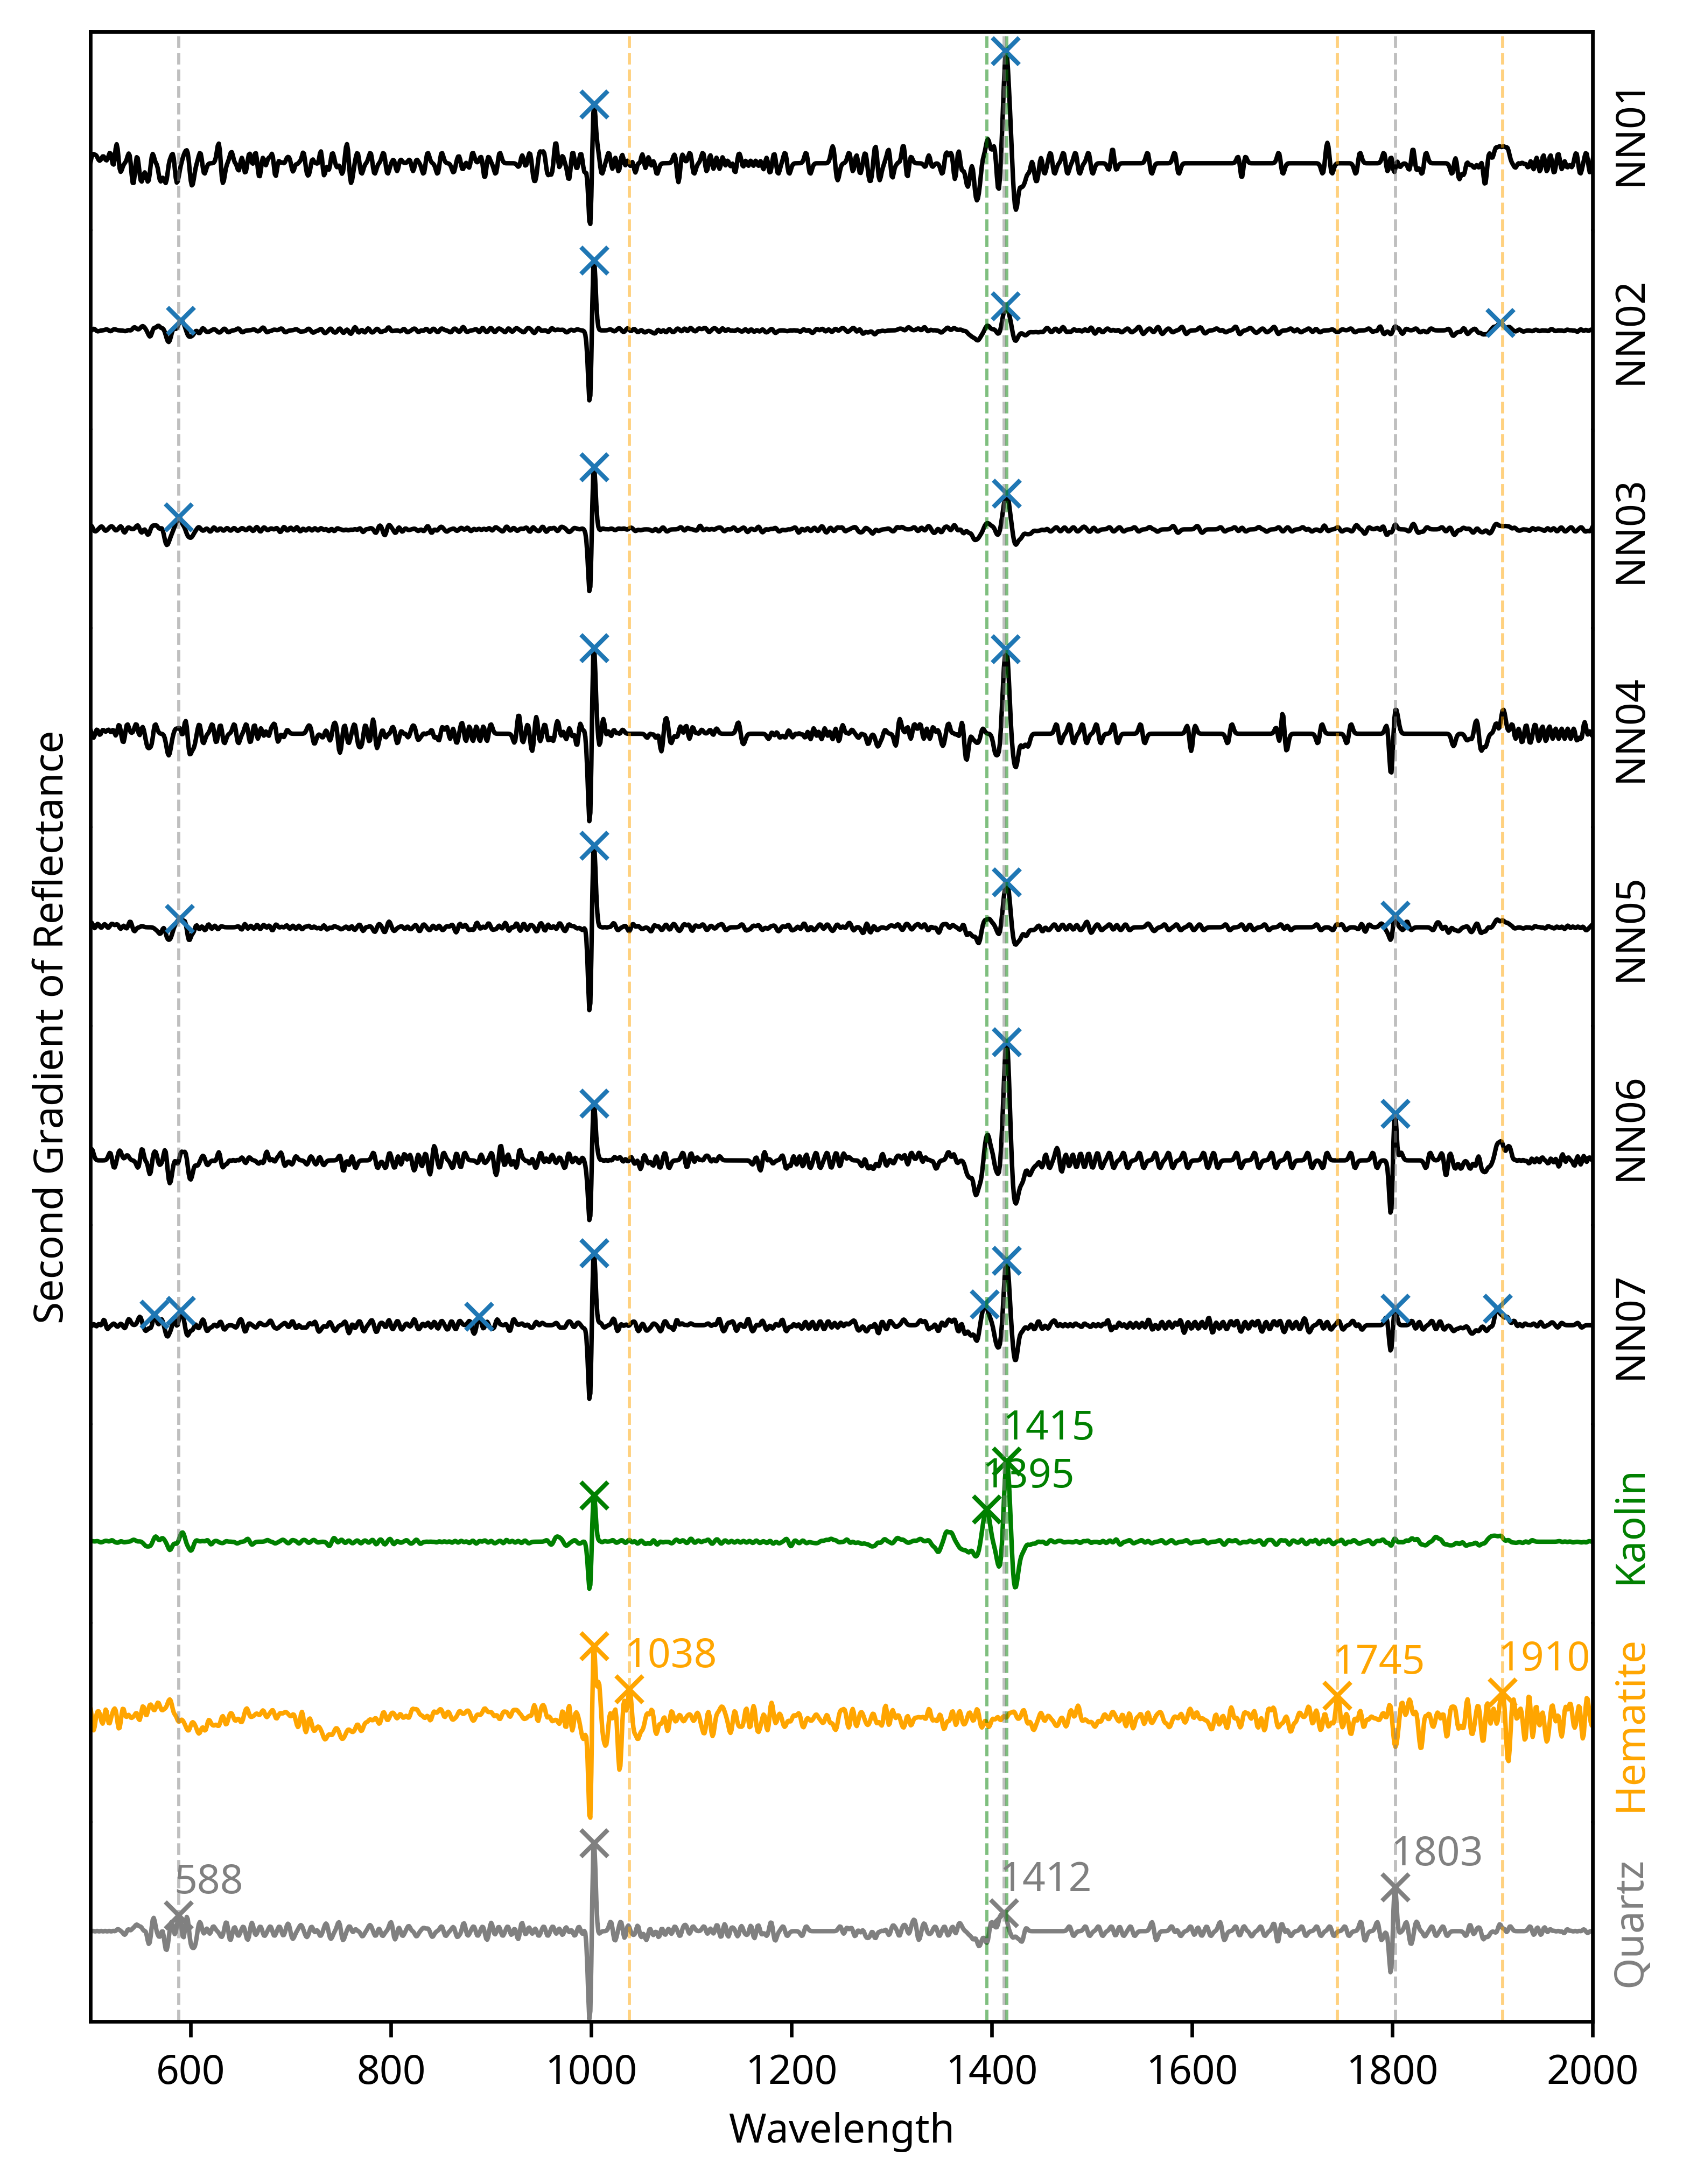

In [69]:
plt.figure(figsize=(6,8)) # Set plot dimensions
plt.subplots_adjust(hspace=0) # Make subplots have no vertical space between them
frame1 = plt.gca() # Set frame for plot to not show ticks
frame1.axes.get_yaxis().set_ticks([])
frame1.axes.get_xaxis().set_ticks([])
plt.ylabel('Second Gradient of Reflectance') # Label y axis

plt.subplot(10,1,1)
culturalplot(n1w,n1y,n1px,n1py,-0.00034,0.00066,'NN01',top=True)

plt.subplot(10,1,2)
culturalplot(n2w,n2y,n2px,n2py,-0.0028,0.0028,'NN02')

plt.subplot(10,1,3)
culturalplot(n3w,n3y,n3px,n3py,-0.0025,0.0025,'NN03')

plt.subplot(10,1,4)
culturalplot(n4w,n4y,n4px,n4py,-0.00052,0.00058,'NN04')

plt.subplot(10,1,5)
culturalplot(n5w,n5y,n5px,n5py,-0.0018,0.0018,'NN05')

plt.subplot(10,1,6)
culturalplot(n6w,n6y,n6px,n6py,-0.00045,0.00092,'NN06')

plt.subplot(10,1,7)
culturalplot(n7w,n7y,n7px,n7py,-0.0012,0.0012,'NN07')

plt.subplot(10,1,8)
modelplot(kw,ky,kpx,kpy,-0.0028,0.004,'Kaolin','Green')

plt.subplot(10,1,9)
modelplot(hw,hy,hpx,hpy,-0.00012,0.00011,'Hematite','Orange')

plt.subplot(10,1,10)
modelplot(qw,qy,qpx,qpy,-0.001,0.0012,'Quartz','Grey',bottom=True)